In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from scipy.special import erf

In [2]:
# Now let use see why linear regression fails for Logisic REGERESSION to begin with
# y^ = w.x  + b
# y^​∈(−∞,∞)

In [3]:
# We have literally nothing at this point here , no mechanism to classify the points into groups.
# Also our current line is not a classifying one what it does is try to fit all the points closer to the 
# As we know in Linear Regression we try to minimize the points by building a generalize model having no systematic
# error and only random error minimizing loss using MSE.

In [4]:
# What we want is some sort of probability where we can have two probabilities for a point 
# One for it belonging to +ve class and other in -ve class (Assuming we are doing Binary Classification)


In [5]:
df = pd.DataFrame({
    'size' : np.array([1,2,3,5,6,8]),
    'label' : np.array([0,0,0,1,1,1])
})

In [6]:
class LR:
    def __init__(self):
        self.coef = None
        self.intercept = None

    def fit(self,X,y):
        # Convert X to a 2D array if it is 1D
        if X.ndim == 1:
            X = X.reshape(-1, 1)

        X = np.insert(X,0,1,axis=1)
        W = np.linalg.inv(np.dot(np.transpose(X),X)).dot(np.transpose(X)).dot(y)

        self.coef = W[1:]
        self.intercept = W[:1]

    def predict(self,X):
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        return np.dot(X,self.coef) + self.intercept

In [7]:
test_df = pd.DataFrame({'size_sample' : np.array([-2,0,1,4,8,12,20])})

In [8]:
model = LR()
model.fit(df['size'].values,df['label'].values)

In [9]:
test_df['predictions'] = model.predict(test_df['size_sample'].values)

In [10]:
test_df

,size_sample,predictions
0,-2,-0.650718
1,0,-0.277512
2,1,-0.090909
3,4,0.468900
4,8,1.215311
5,12,1.961722
6,20,3.454545


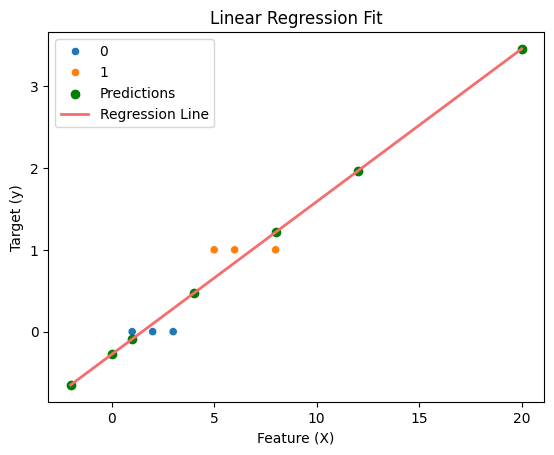

In [11]:
# Plot the regression line

X_line = np.linspace(-2,20,300)
y_line = model.predict(X_line)

sns.scatterplot(data = df,x='size',y='label',hue='label')
plt.scatter(
    test_df["size_sample"],
    test_df["predictions"],
    color="green",
    label="Predictions"
)
plt.plot(X_line, y_line, color="#F76C6C", linewidth=2, label="Regression Line")

plt.xlabel("Feature (X)")
plt.ylabel("Target (y)")
plt.title("Linear Regression Fit")
plt.legend()
plt.show()

In [12]:
# Look closely , our line wants to touch points not seperate them.
# Cause that's the reason it was designed to begin with nothing concerned with probabilites and classification
# It has no knowledge of labels at all

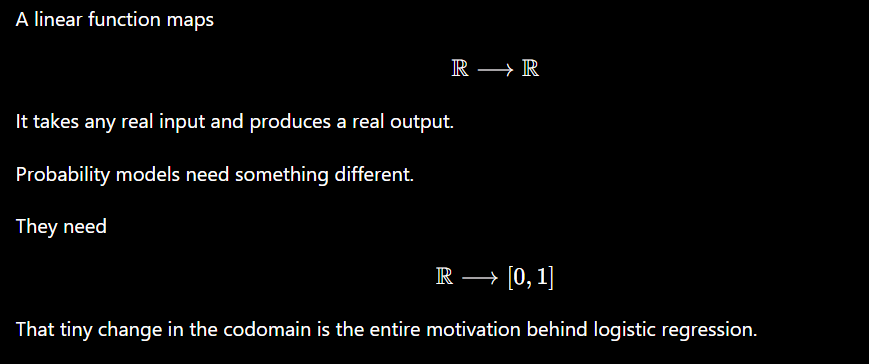

In [13]:
""" 
    Linear Regression minimizes squared error and therefore learns a linear function over the real numbers. 
Because a linear function is unbounded, its predictions are not guaranteed to lie within the interval [0,1].
Consequently, although some predictions may resemble probabilities, the model provides no mathematical guarantee 
that its outputs are valid probabilities.
"""

' \n    Linear Regression minimizes squared error and therefore learns a linear function over the real numbers. \nBecause a linear function is unbounded, its predictions are not guaranteed to lie within the interval [0,1].\nConsequently, although some predictions may resemble probabilities, the model provides no mathematical guarantee \nthat its outputs are valid probabilities.\n'

In [14]:
# What our requirement 
#  > We need probability not a score z
#  > We need it in the range [0,1] axiom
#  > We can use our linear function but how ?
#  > If scores are are suppose 2 and 5 for tumor A and B respectively :  then their transformed probabilites function must be f(5)>f(2)
#  > Graph is monotonically incresaing and looks like : 
""" 
              1 |              ______
                |            /
                |           /
            0.5 |----------/
                |         /
                |        /
              0 |    ___/
"""
#   > Large values let's say 20 are close to 1 should be classifiying greatly and having a value of closer to 1 
#   > IF z = 0 : ---> No preference
#                   This immediately gives us a decision rule:

                # z>0 → probability > 0.5
                # z<0 → probability < 0.5

# What we want is : 
#     Input x
#       │
#       ▼
# Linear Model
# z = wx+b
#       │
#       ▼
#  ?????????
#       │
#       ▼
# Probability

""" 
| Requirement                       | Reason                                  |
| --------------------------------- | --------------------------------------- |
| Output is always in ((0,1))       | Valid probabilities                     |
| Monotonically increasing          | Preserve ranking of scores              |
| Smooth and differentiable         | Gradient descent needs gradients        |
| (f(0)=0.5)                        | Zero score means no preference          |
| Approaches 0 and 1 asymptotically | Never predicts impossible probabilities |

"""

' \n| Requirement                       | Reason                                  |\n| --------------------------------- | --------------------------------------- |\n| Output is always in ((0,1))       | Valid probabilities                     |\n| Monotonically increasing          | Preserve ranking of scores              |\n| Smooth and differentiable         | Gradient descent needs gradients        |\n| (f(0)=0.5)                        | Zero score means no preference          |\n| Approaches 0 and 1 asymptotically | Never predicts impossible probabilities |\n\n'

In [15]:
# Why not step function ? 
# Gradient is 0 step is teleporting
""" 
Graph looks like : 
1 |_________
  |
  |
0 |_________
"""

' \nGraph looks like : \n1 |_________\n  |\n  |\n0 |_________\n'

In [16]:
# Different Possible candidates for Classification

def linear(z):
    return 0.5 + 0.1*z

def step(z):
    return (z >= 0).astype(float)

def arctan_squash(z):
    return np.arctan(z)/np.pi + 0.5

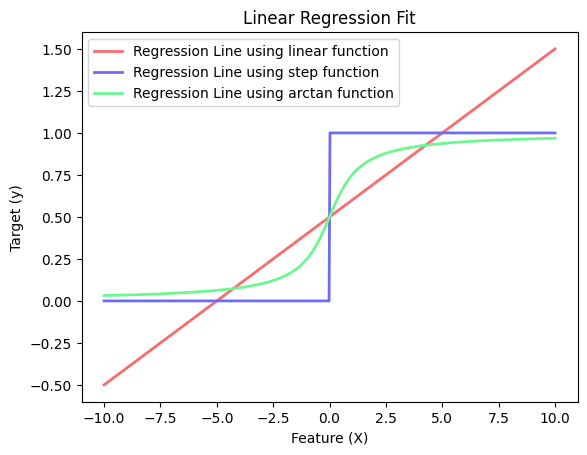

In [17]:
# Plot the regression line
z = np.linspace(-10, 10, 500)

plt.plot(z, linear(z), color="#F76C6C", linewidth=2, label="Regression Line using linear function")
plt.plot(z, step(z), color="#6E6CF7", linewidth=2, label="Regression Line using step function")
plt.plot(z, arctan_squash(z), color="#6CF78F", linewidth=2, label="Regression Line using arctan function")

plt.xlabel("Feature (X)")
plt.ylabel("Target (y)")
plt.title("Linear Regression Fit")
plt.legend()
plt.show()

In [18]:
# Now let's take some other possible candidates and plot them to look which candidate works
# How are these build based on our requirements which we discussed before

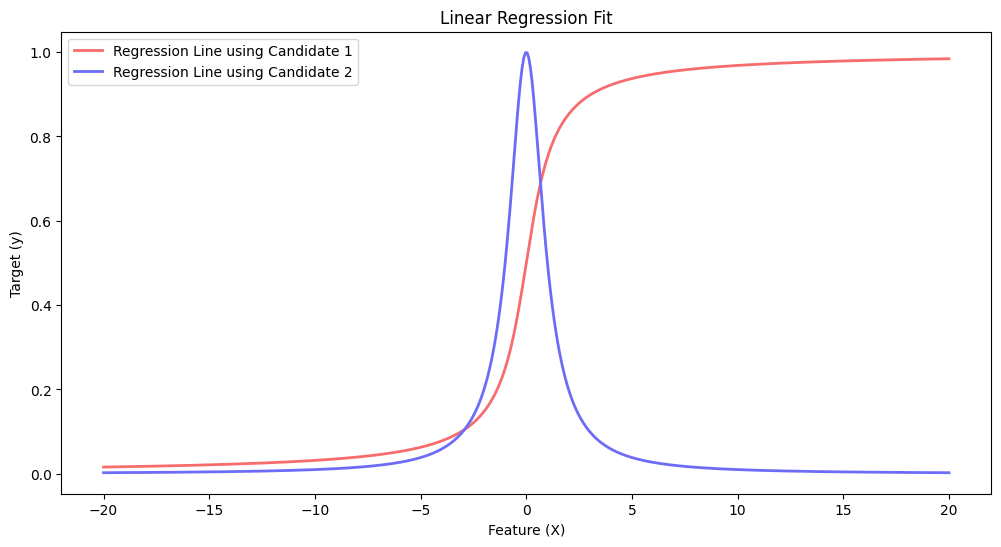

In [19]:
# Candidate 1
def f1(z):
    return np.arctan(z)/np.pi + 0.5

# Candidate 2
def f2(z):
    return 1/(1+z**2)

z = np.linspace(-20,20,500)

plt.figure(figsize=(12,6))
plt.plot(z, f1(z), color="#F76C6C", linewidth=2, label="Regression Line using Candidate 1")
plt.plot(z, f2(z), color="#6E6CF7", linewidth=2, label="Regression Line using Candidate 2")


plt.xlabel("Feature (X)")
plt.ylabel("Target (y)")
plt.title("Linear Regression Fit")
plt.legend()
plt.show()

In [20]:
# Defining odds : 
""" 
| Probability | Odds  |
| ----------- | ----- |
| 0           | 0     |
| 0.1         | 0.111 |
| 0.2         | 0.25  |
| 0.5         | 1     |
| 0.8         | 4     |
| 0.9         | 9     |
| 0.99        | 99    |
Odds=p/1-p ( Likeliness of an event happening)
"""

' \n| Probability | Odds  |\n| ----------- | ----- |\n| 0           | 0     |\n| 0.1         | 0.111 |\n| 0.2         | 0.25  |\n| 0.5         | 1     |\n| 0.8         | 4     |\n| 0.9         | 9     |\n| 0.99        | 99    |\nOdds=p/1-p ( Likeliness of an event happening)\n'

In [21]:
# Odds cannot be mapped to our linear equation because it is in the range of 0 to inf  as proba can never be negative
# To make them we take the log of odds.

In [22]:
# Now we can say that log(p/1-p) = beta_1.x + beta_0

In [23]:
# Now let's take some probabilites and look for how transformations affect them

In [24]:
probas = pd.DataFrame({
    'probability' : np.array([0.01,0.1,0.5,0.9,0.99])
})
probas['odds'] = probas['probability'] / (1 - probas['probability']) # Calculate odds
probas['log-odds'] = np.log(probas['odds']) # Calculate log-odds

In [25]:
probas

,probability,odds,log-odds
0,0.01,0.010101,-4.595120
1,0.10,0.111111,-2.197225
2,0.50,1.000000,0.000000
3,0.90,9.000000,2.197225
4,0.99,99.000000,4.595120


In [26]:
# We can clearly see that ass the probability increases the the odds increases and notice how the odds are never negative because probaas are never -ve.
# The logarithm transforms the strictly positive odds into a quantity whose range is the entire real line, making it compatible with a linear model.

In [27]:
# We can now finally have a connection between probas and our linear equation : 
# log(p/1-p) = beta_1.x + beta_0

In [28]:
# Now deriving the proba P from this  : 
""" 
Solving :
            log(p/1-p) = z 
                p/1-p = e^z 
                    p= e^z-p. e^z
                        p+p. e^z =  e^z
                            p(1+ e^z) =  e^z
                                p =  e^z/(1+ e^z)
"""

' \nSolving :\n            log(p/1-p) = z \n                p/1-p = e^z \n                    p= e^z-p. e^z\n                        p+p. e^z =  e^z\n                            p(1+ e^z) =  e^z\n                                p =  e^z/(1+ e^z)\n'

In [29]:
# Logistic Regression models the log-odds linearly. 
# The sigmoid is simply the inverse transformation that converts those log-odds back into probabilities.

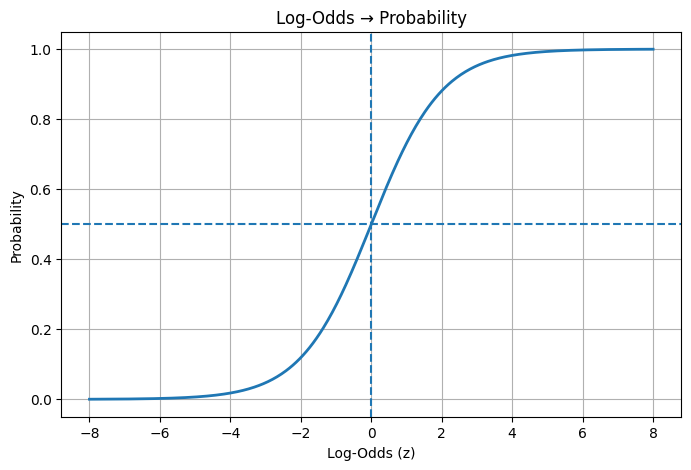

In [30]:
z = np.linspace(-8, 8, 500)

p = np.exp(z) / (1 + np.exp(z))

plt.figure(figsize=(8,5))
plt.plot(z, p, linewidth=2)
plt.axvline(0, linestyle="--")
plt.axhline(0.5, linestyle="--")

plt.xlabel("Log-Odds (z)")
plt.ylabel("Probability")
plt.title("Log-Odds → Probability")
plt.grid(True)

plt.show()

In [31]:
# This is what happens when we place our linear equation z in the sigmoid function

In [32]:
# Also sigmoid(z) = 1 - sigmoid(-z)
""" 
sigmoid(z) =  e^z/1+e^z
    sigmoid(-z) = e^-z/1+e^-z
        =  e^-z/(1+(1/e^z))
        =   e^-z.e^z/(1+ e^z)
        =    1/1+e^z
"""

' \nsigmoid(z) =  e^z/1+e^z\n    sigmoid(-z) = e^-z/1+e^-z\n        =  e^-z/(1+(1/e^z))\n        =   e^-z.e^z/(1+ e^z)\n        =    1/1+e^z\n'

Calculated values:
 z = -10.0  -> p = 0.0000
Calculated values:
 z = -2.0  -> p = 0.1192
Calculated values:
 z = -0.001  -> p = 0.4998
Calculated values:
 z = 0.0  -> p = 0.5000
Calculated values:
 z = 0.111  -> p = 0.5277
Calculated values:
 z = 5.0  -> p = 0.9933
Calculated values:
 z = 10.0  -> p = 1.0000


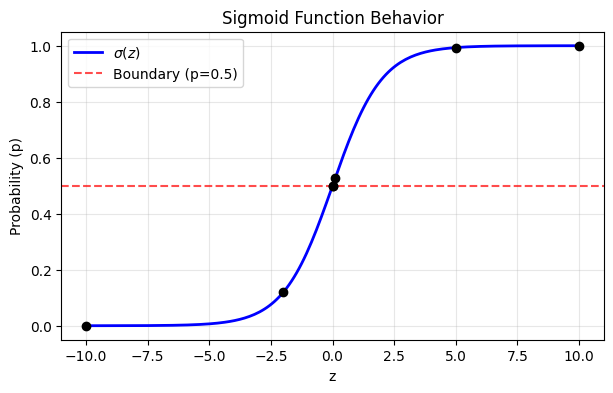

In [33]:
# Sigmoid definition
sigma = lambda z: 1 / (1 + np.exp(-z))

# Behaviou of sigmoid across various values of z (linear equation)
z_points = np.array([-10,-2,-0.001,0,0.111,5,10])
p_points = sigma(z_points)
for i in range(len(z_points)) : 
    print(f'Calculated values:\n z = {z_points[i]}  -> p = {p_points[i]:.4f}')

# Plotting the behavior
z = np.linspace(-10, 10, 200)
plt.figure(figsize=(7, 4))
plt.plot(z, sigma(z), label=r'$\sigma(z)$', color='blue', lw=2)
plt.axhline(0.5, color='red', linestyle='--', alpha=0.7, label='Boundary (p=0.5)')
plt.scatter(z_points, p_points, color='black', zorder=5)

plt.title('Sigmoid Function Behavior')
plt.xlabel('z')
plt.ylabel('Probability (p)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


In [34]:
# The proability of 0.5 is the decision threshold where below or above each are two seperate classes .
# You can clearly spot that for values greater than 0 the sigmoid will be able to classify the points as +ve class 
# and the negative z values as -ve class.

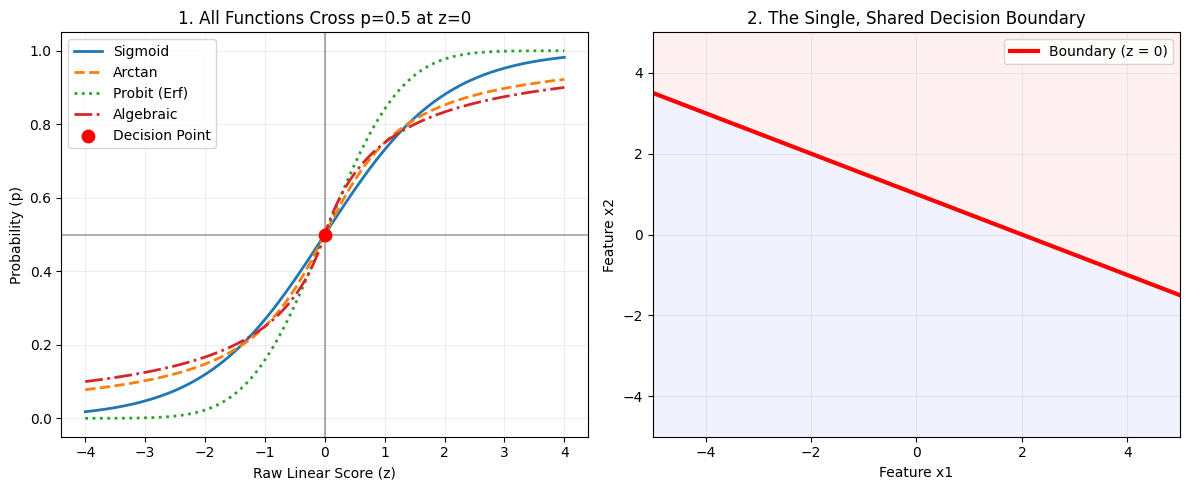

In [35]:
# Also the decision boundary is fixated at z = 0 regardless of any monotonic function.
# To actually look for this is true we will use differnt functions and check

# 1. Define four completely different monotonic squashing functions (all cross 0.5 at z=0)
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def scaled_arctan(z):
    return (np.arctan(z) / np.pi) + 0.5

def probit(z):
    return 0.5 * (1 + erf(z / np.sqrt(2)))

def algebraic(z):
    return 0.5 * (z / (1 + np.abs(z))) + 0.5

# 2. Choose parameters for our linear equation: z = b0 + b1*x1 + b2*x2
b0, b1, b2 = -1.0, 0.5, 1.0

# Set up the plotting window side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- GRAPH 1: Probability curves vs. Raw Score z ---
z_vals = np.linspace(-4, 4, 300)

ax1.plot(z_vals, sigmoid(z_vals), label='Sigmoid', lw=2)
ax1.plot(z_vals, scaled_arctan(z_vals), label='Arctan', lw=2, linestyle='--')
ax1.plot(z_vals, probit(z_vals), label='Probit (Erf)', lw=2, linestyle=':')
ax1.plot(z_vals, algebraic(z_vals), label='Algebraic', lw=2, linestyle='-.')

# Highlight the magic crossroad at z=0, p=0.5
ax1.axvline(0, color='black', linestyle='-', alpha=0.3)
ax1.axhline(0.5, color='black', linestyle='-', alpha=0.3)
ax1.scatter(0, 0.5, color='red', s=80, zorder=5, label='Decision Point')

ax1.set_title('1. All Functions Cross p=0.5 at z=0')
ax1.set_xlabel('Raw Linear Score (z)')
ax1.set_ylabel('Probability (p)')
ax1.legend()
ax1.grid(True, alpha=0.2)

# --- GRAPH 2: The exact spatial boundary in the x1, x2 grid ---
x1_grid = np.linspace(-5, 5, 100)
# Solve b0 + b1*x1 + b2*x2 = 0 for x2 -> x2 = (-b0 - b1*x1) / b2
x2_boundary = (-b0 - b1 * x1_grid) / b2

ax2.plot(x1_grid, x2_boundary, color='red', lw=3, label='Boundary (z = 0)')

# Visualise the separation zones (Z > 0 vs Z < 0)
X1, X2 = np.meshgrid(np.linspace(-5, 5, 100), np.linspace(-5, 5, 100))
Z = b0 + b1*X1 + b2*X2
ax2.contourf(X1, X2, Z > 0, cmap='bwr', alpha=0.1)

ax2.set_title('2. The Single, Shared Decision Boundary')
ax2.set_xlabel('Feature x1')
ax2.set_ylabel('Feature x2')
ax2.set_xlim(-5, 5)
ax2.set_ylim(-5, 5)
ax2.legend()
ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

In [36]:
# We cal clearly see that now matter what monotonic function we take the descision boundary is always at z = 0 and probability 0.5

In [38]:
# We did all this but how are we gonna update params  ?
# Do we use MSE like LinearRegression  ? Let's try :

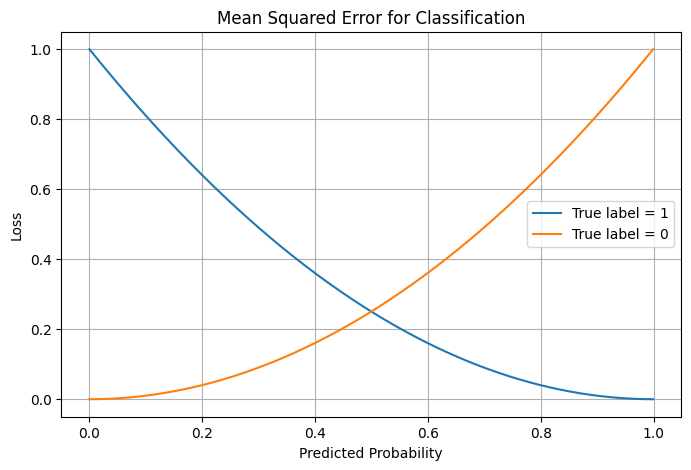

In [42]:
p = np.linspace(0.001, 0.999, 500)

# We are using the same mse function for our sigmoid function
mse_y1 = (1 - p)**2 # When prediction is 1 and actual probability p
mse_y0 = p**2 # When prediction is 0 and actual probability p

plt.figure(figsize=(8,5))

plt.plot(p, mse_y1, label="True label = 1")
plt.plot(p, mse_y0, label="True label = 0")

plt.xlabel("Predicted Probability")
plt.ylabel("Loss")
plt.title("Mean Squared Error for Classification")
plt.grid(True)
plt.legend()

plt.show()

In [40]:
# Looking at the behaviour we see how losses of both labels are polar opposites 
# Their proabibility loss is equal at the decision boundary

In [41]:
# If this is reasonable then why do we even need a new loss function ?
# Let's dive deeper

In [44]:
# In differentiating the sigmoid for calculating gradients for our parameters we get : 
# derivative(sigmoid(z)) == sigmoid(z) (1-sigmoid(z))

In [52]:
# Let's plot these values

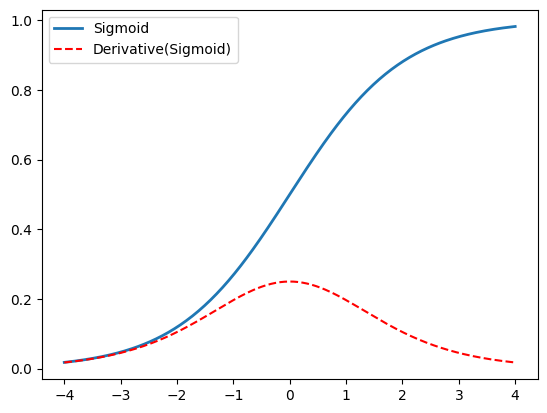

In [63]:
z_vals = np.linspace(-4, 4, 300)

def derivative_sigmoid(z):
    return sigmoid(z)*(1-sigmoid(z))

plt.plot(z_vals, sigmoid(z_vals), label='Sigmoid', lw=2)
plt.plot(z_vals,derivative_sigmoid(z_vals),"--",label='Derivative(Sigmoid)',lw=1.5,color='red')
plt.legend()
plt.show()


In [64]:
# 1. Setup the scenario where true label y = 1
y = 1
p_values = np.array([0.999, 0.8, 0.6, 0.5, 0.4, 0.2, 0.1, 0.01, 0.001])

# 2. Calculate each piece of the chain rule derivation
error_term = y - p_values              # (y - p)
dL_dp = -2 * error_term                # dL/dp for MSE
dp_dz = p_values * (1 - p_values)      # dp/dz (Sigmoid derivative)
dL_dz = dL_dp * dp_dz                  # Combined gradient (dL/dp * dp/dz)

# 3. Create the DataFrame
df = pd.DataFrame({
    'Prediction (p)': p_values,
    'True Label (y)': y,
    'Error (y - p)': error_term,
    'dL/dp (MSE)': dL_dp,
    'dp/dz (Sigmoid)': dp_dz,
    'Final dL/dz (Combined)': dL_dz,
    'Gradient Magnitude': np.abs(dL_dz)
})

df


,Prediction (p),True Label (y),Error (y - p),dL/dp (MSE),dp/dz (Sigmoid),Final dL/dz (Combined),Gradient Magnitude
0,0.999,1,0.001,-0.002,0.000999,-0.000002,0.000002
1,0.800,1,0.200,-0.400,0.160000,-0.064000,0.064000
2,0.600,1,0.400,-0.800,0.240000,-0.192000,0.192000
3,0.500,1,0.500,-1.000,0.250000,-0.250000,0.250000
4,0.400,1,0.600,-1.200,0.240000,-0.288000,0.288000
5,0.200,1,0.800,-1.600,0.160000,-0.256000,0.256000
6,0.100,1,0.900,-1.800,0.090000,-0.162000,0.162000
7,0.010,1,0.990,-1.980,0.009900,-0.019602,0.019602
8,0.001,1,0.999,-1.998,0.000999,-0.001996,0.001996


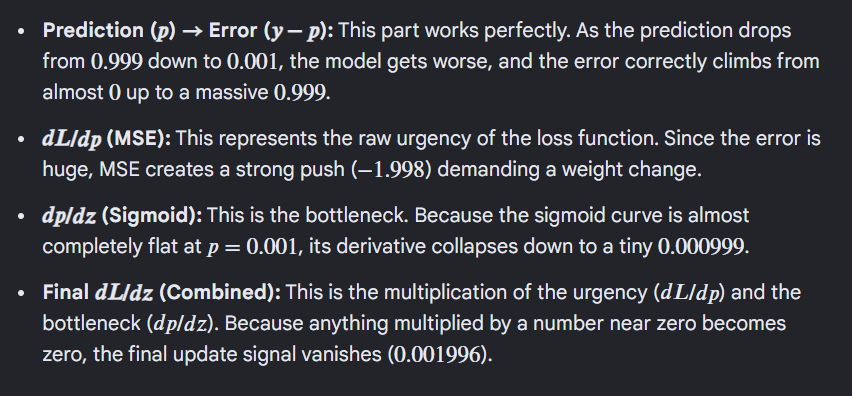
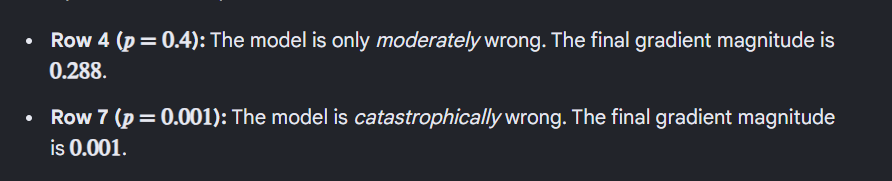

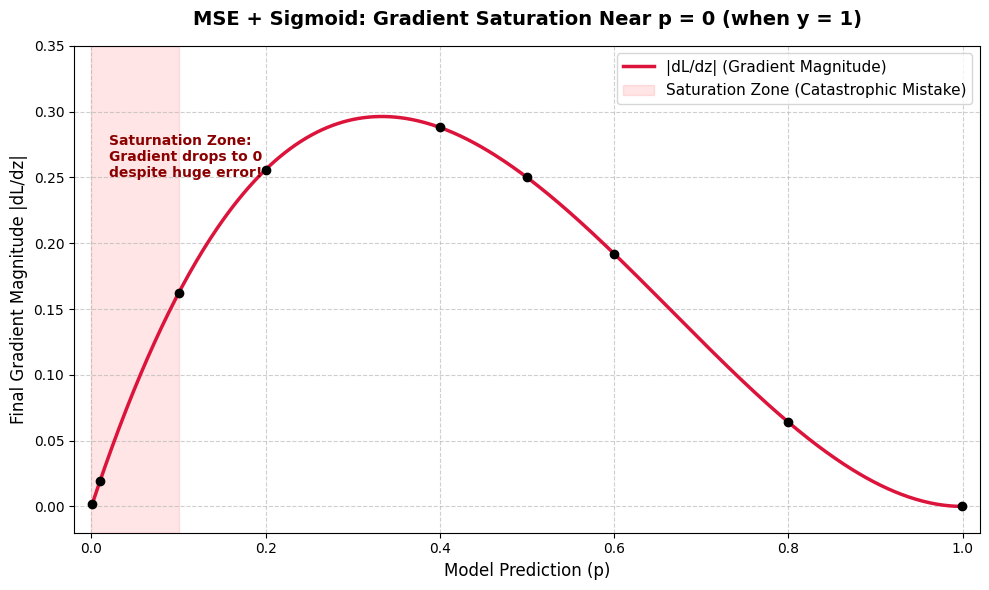

In [65]:
# 4. Generate a smooth curve for plotting
p_smooth = np.linspace(0, 1, 500)
dp_dz_smooth = p_smooth * (1 - p_smooth)
dL_dz_smooth = -2 * (y - p_smooth) * dp_dz_smooth
gradient_mag_smooth = np.abs(dL_dz_smooth)

# 5. Plotting the results using Matplotlib
plt.figure(figsize=(10, 6))
plt.plot(p_smooth, gradient_mag_smooth, color='crimson', lw=2.5, label='|dL/dz| (Gradient Magnitude)')

# Highlight the specific points from our dataframe
plt.scatter(df['Prediction (p)'], df['Gradient Magnitude'], color='black', zorder=5)

# Annotate the saturation zone
plt.axvspan(0, 0.1, color='red', alpha=0.1, label='Saturation Zone (Catastrophic Mistake)')
plt.text(0.02, 0.25, 'Saturnation Zone:\nGradient drops to 0\ndespite huge error!', 
         color='darkred', fontsize=10, fontweight='bold')

# Graph styling
plt.title('MSE + Sigmoid: Gradient Saturation Near p = 0 (when y = 1)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Model Prediction (p)', fontsize=12)
plt.ylabel('Final Gradient Magnitude |dL/dz|', fontsize=12)
plt.xlim(-0.02, 1.02)
plt.ylim(-0.02, 0.35)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()

In [ ]:
# The sigmoid has gradient saturation 